# 04 - Quantum Kernel and QSVC

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Builds a Qiskit quantum feature map, visualizes the resulting fidelity **quantum kernel**
matrix, and trains a **QSVC** (Quantum Kernel -> Support Vector Classifier) on a small toy
dataset. Kernel evaluation is O(n^2) circuit evaluations, so training stays small here —
`src/experiments/run_quantum.py --model qsvc` is the entry point for larger runs.

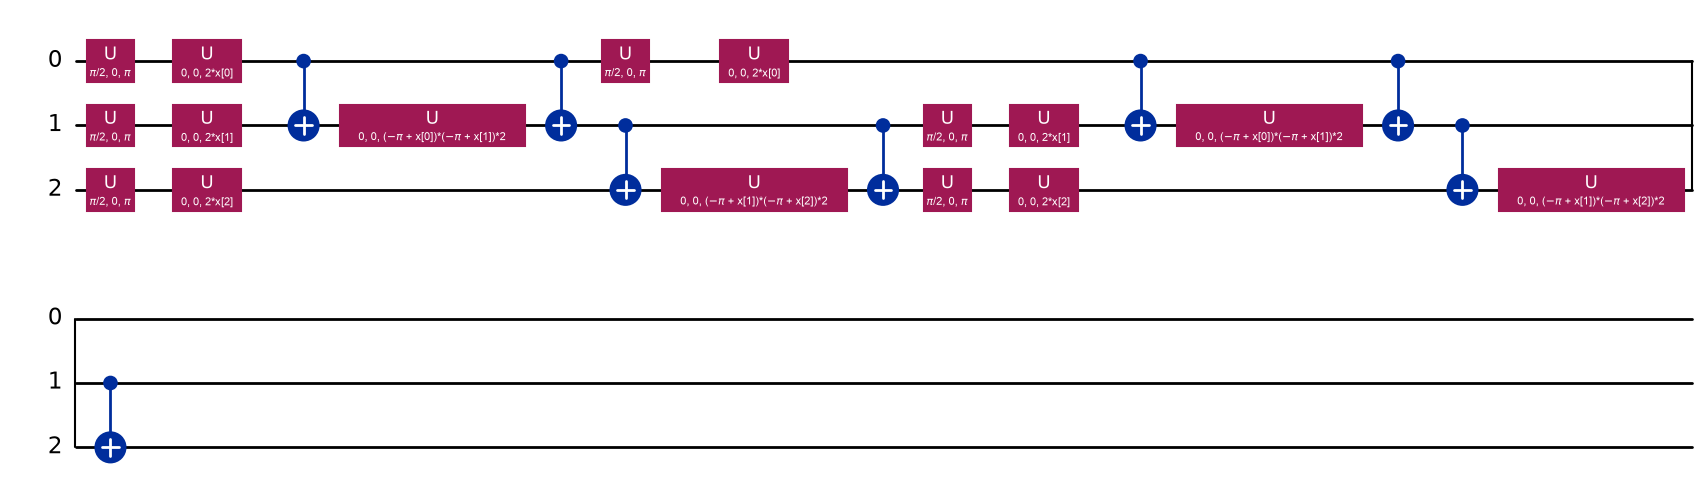

In [2]:
from src.quantum.feature_maps import build_feature_map
from src.quantum.circuit_metrics import compute_circuit_metrics

feature_map = build_feature_map("zz", num_qubits=3, reps=2, entanglement="linear")
fig = feature_map.decompose().draw("mpl", style="iqp")
fig.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\04_zz_feature_map_circuit.png", bbox_inches="tight")
fig


In [3]:
metrics = compute_circuit_metrics(feature_map)
print(metrics)


CircuitMetrics(num_qubits=3, logical_depth=16, logical_gate_count=24, transpiled_depth=20, transpiled_gate_count=36, two_qubit_gate_count=8, optimization_level=1)


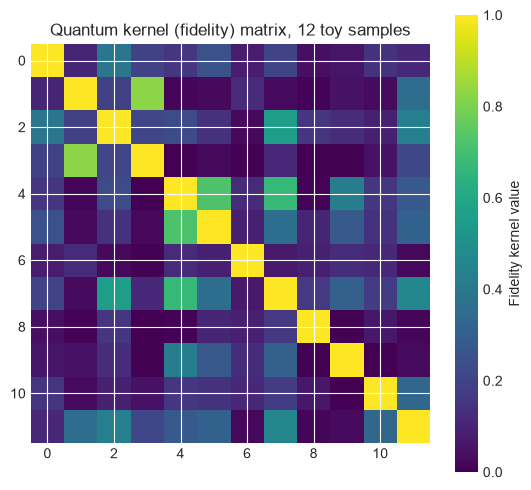

In [4]:
import numpy as np
from src.quantum.noise_models import get_primitives
from src.quantum.quantum_kernel import build_quantum_kernel

rng = np.random.default_rng(0)
X_toy = rng.uniform(-1, 1, size=(12, 3))

primitives = get_primitives(backend="simulator", shots=256, seed=42)
kernel_bundle = build_quantum_kernel(feature_map, primitives)
K = kernel_bundle.kernel.evaluate(x_vec=X_toy)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(K, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="Fidelity kernel value")
ax.set_title("Quantum kernel (fidelity) matrix, 12 toy samples")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\04_quantum_kernel_matrix.png")
plt.show()


In [5]:
from src.quantum.qsvc_model import QSVCModel
from src.evaluation.metrics import compute_metrics

rng = np.random.default_rng(1)
X = rng.normal(size=(40, 3))
y = (X[:, 0] + X[:, 1] > 0).astype(int)
X_train, y_train = X[:28], y[:28]
X_test, y_test = X[28:], y[28:]

qsvc = QSVCModel(num_qubits=3, backend="simulator", shots=256, seed=42)
fit_result = qsvc.fit(X_train, y_train)
proba = qsvc.predict_proba(X_test)
m = compute_metrics(y_test, proba, threshold=0.5)
print(fit_result)
print(f"PR-AUC={m.pr_auc:.3f}  ROC-AUC={m.roc_auc:.3f}  Recall={m.recall:.3f}  FPR={m.fpr:.3f}")


QuantumFitResult(training_time_s=5.806855199974962, n_train=28, num_qubits=3, circuit_depth=16, transpiled_depth=20, shots=256, backend_name='aer_simulator')
PR-AUC=0.768  ROC-AUC=0.600  Recall=0.571  FPR=0.600


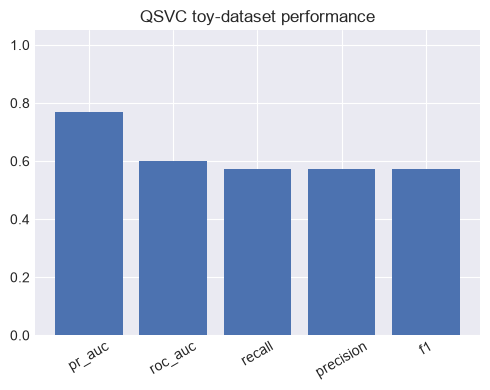

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
metric_names = ["pr_auc", "roc_auc", "recall", "precision", "f1"]
values = [getattr(m, name) for name in metric_names]
ax.bar(metric_names, values, color="#4C72B0")
ax.set_ylim(0, 1.05)
ax.set_title("QSVC toy-dataset performance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\04_qsvc_metrics.png")
plt.show()
